In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df_Wipro = pd.read_csv("Data\IT_Data\WIPRO.NS_data.csv")

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\vishe\AppData\Local\Temp\ipykernel_25580\301704616.py:1: SyntaxWarning: invalid escape sequence '\I'
  df_Wipro = pd.read_csv("Data\IT_Data\WIPRO.NS_data.csv")


In [3]:
df_Wipro.info()

<class 'pandas.DataFrame'>
RangeIndex: 2759 entries, 0 to 2758
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   2759 non-null   str  
 1   Close   2758 non-null   str  
 2   High    2758 non-null   str  
 3   Low     2758 non-null   str  
 4   Open    2758 non-null   str  
 5   Volume  2758 non-null   str  
dtypes: str(6)
memory usage: 129.5 KB


In [4]:
df_Wipro.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,WIPRO.NS,WIPRO.NS,WIPRO.NS,WIPRO.NS,WIPRO.NS
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-01,91.15482330322266,91.48485516104658,90.84128900958073,91.17957300675332,1082549
3,2015-01-02,91.96337890625,92.45017444902535,91.25380922151129,91.31981960759971,4198953
4,2015-01-05,92.12840270996094,93.23400794810327,91.66635682572571,91.92213282543757,3838601


In [5]:
df_Wipro.describe()

,Price,Close,High,Low,Open,Volume
count,2759,2758,2758,2758,2758,2758
unique,2759,2600,2751,2757,2756,2756
top,Ticker,99.89064025878906,92.4224374290036,98.24265541630028,97.84781353159028,11205821
freq,1,5,2,2,2,2


In [6]:
df_Wipro = df_Wipro.rename(columns={'Price':'Date'})

In [7]:
df_Wipro = df_Wipro.iloc[2:].reset_index(drop=True)

In [8]:
df_Wipro['Date'] = pd.to_datetime(df_Wipro['Date'])

decimal_values = ["Close", "High", "Low", "Open", "Volume"]
numeric_values =["Volume"]

for i in decimal_values:
    df_Wipro[i] = df_Wipro[i].astype(float)

for j in numeric_values:
    df_Wipro[j] = pd.to_numeric(df_Wipro[j])

In [9]:
df_Wipro = df_Wipro.sort_values(by="Date").reset_index(drop=True)

### Visualize The Trends

In [10]:
import matplotlib.pyplot as plt

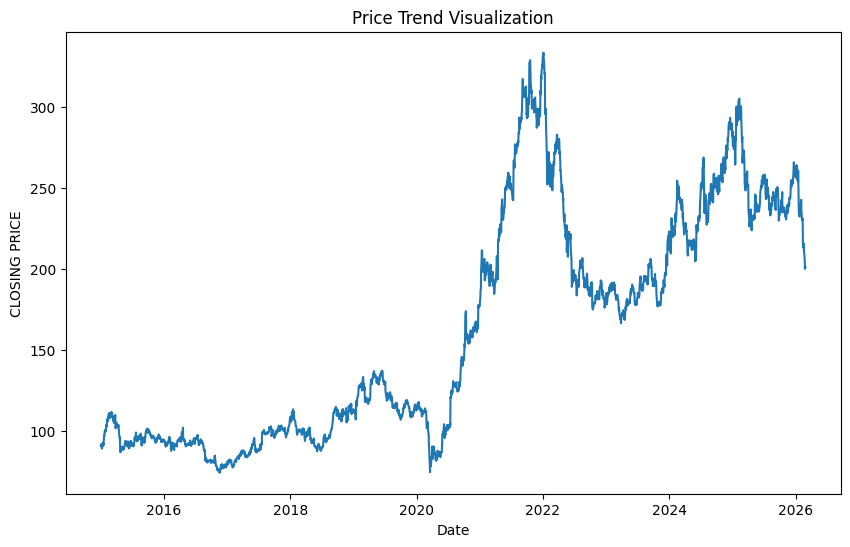

In [11]:
# Price Trend Over the Time
plt.figure(figsize=(10,6))
plt.plot(df_Wipro['Date'], df_Wipro['Close'], )
plt.title("Price Trend Visualization")
plt.xlabel("Date")
plt.ylabel("CLOSING PRICE")
plt.show()

<Figure size 1000x600 with 0 Axes>

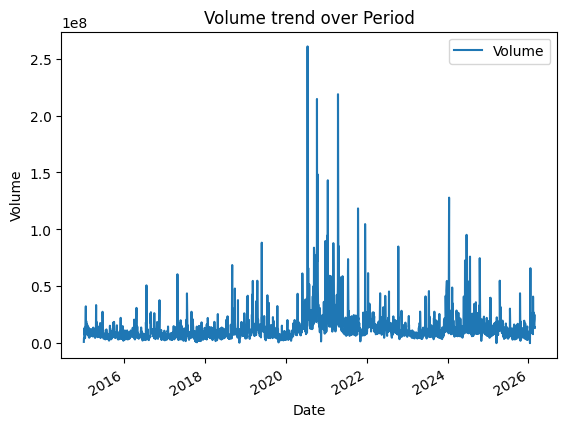

In [12]:
# Volume trend Over Time
plt.figure(figsize=(10,6))
df_Wipro.plot(x='Date', y='Volume', kind='line', title="Volume trend over Period")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

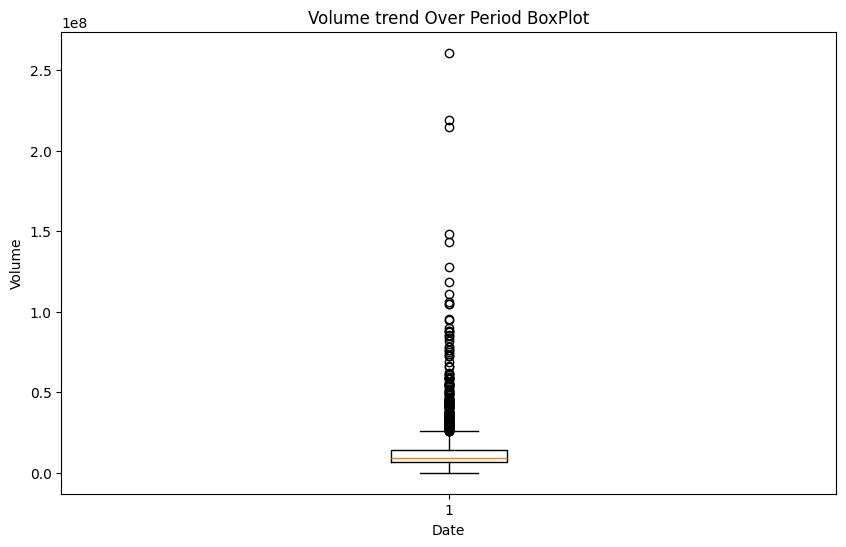

In [13]:
# The Line shows a Outlier in Volume . Check it using Box Plot
plt.figure(figsize=(10,6))
plt.boxplot(df_Wipro["Volume"])
plt.title("Volume trend Over Period BoxPlot")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

# Daily Returns on Stocks

In [14]:
def daily_returns(close_price):
    returns=[None]
    for i in range(1, len(close_price)):
        daily_return = (close_price[i] - close_price[i-1])/close_price[i-1]
        returns.append(daily_return)
    return returns

df_Wipro['Daily_Returns'] = daily_returns(df_Wipro['Close'])

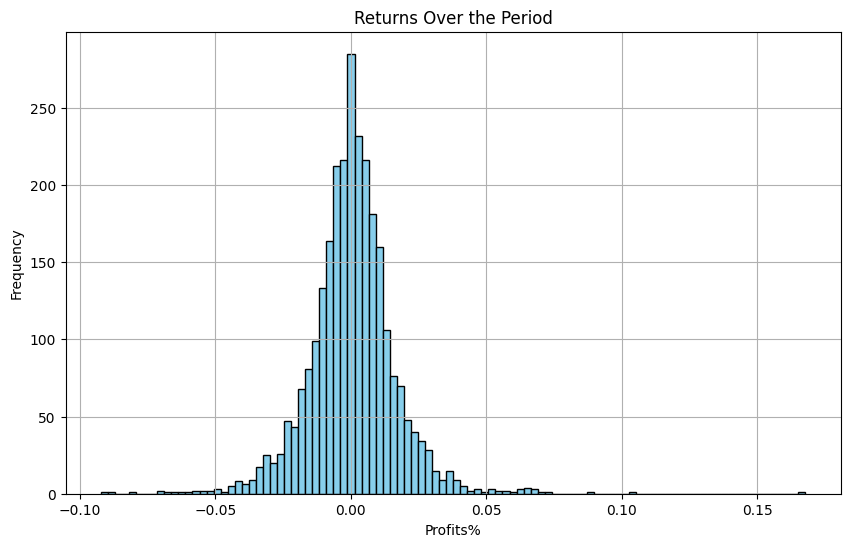

In [15]:
# Visualization of the Returns
plt.figure(figsize=(10,6))
plt.hist(df_Wipro['Daily_Returns'], bins=100, color='skyblue', edgecolor='black')
plt.xlabel("Profits%")
plt.ylabel("Frequency")
plt.title("Returns Over the Period")
plt.grid(True)
plt.show()

In [16]:
df_Wipro

,Date,Close,High,Low,Open,Volume,Daily_Returns
0,2015-01-01,91.154823,91.484855,90.841289,91.179573,1082549.0,NaN
1,2015-01-02,91.963379,92.450174,91.253809,91.319820,4198953.0,0.008870
2,2015-01-05,92.128403,93.234008,91.666357,91.922133,3838601.0,0.001794
3,2015-01-06,89.974930,91.814861,89.455132,91.583835,12396695.0,-0.023375
4,2015-01-07,89.290131,89.933690,88.836337,89.636660,8305581.0,-0.007611
...,...,...,...,...,...,...,...
2752,2026-02-23,205.889999,211.740005,204.279999,210.360001,20946229.0,-0.018917
2753,2026-02-24,200.139999,203.289993,199.360001,203.000000,25036686.0,-0.027928
2754,2026-02-25,201.919998,205.479996,201.309998,201.309998,13979068.0,0.008894
2755,2026-02-26,201.080002,204.630005,199.119995,203.710007,14378069.0,-0.004160


### Calculating Moving Averages Across the Range

In [17]:
df_Wipro['MA_Week'] = df_Wipro['Close'].rolling(window=7).mean()
df_Wipro['MA_Month'] = df_Wipro['Close'].rolling(window=30).mean()
df_Wipro['MA_3Months'] = df_Wipro['Close'].rolling(window=90).mean()

In [18]:
df_Wipro.head(10)

,Date,Close,High,Low,Open,Volume,Daily_Returns,MA_Week,MA_Month,MA_3Months
0,2015-01-01,91.154823,91.484855,90.841289,91.179573,1082549.0,NaN,NaN,NaN,NaN
1,2015-01-02,91.963379,92.450174,91.253809,91.319820,4198953.0,0.008870,NaN,NaN,NaN
2,2015-01-05,92.128403,93.234008,91.666357,91.922133,3838601.0,0.001794,NaN,NaN,NaN
3,2015-01-06,89.974930,91.814861,89.455132,91.583835,12396695.0,-0.023375,NaN,NaN,NaN
4,2015-01-07,89.290131,89.933690,88.836337,89.636660,8305581.0,-0.007611,NaN,NaN,NaN
5,2015-01-08,89.933693,92.227418,89.636663,91.773624,7792131.0,0.007208,NaN,NaN,NaN
6,2015-01-09,91.336311,92.408915,89.644899,90.626742,13587116.0,0.015596,90.825953,NaN,NaN
7,2015-01-12,91.757118,92.243914,90.379233,90.758771,4421790.0,0.004607,90.911995,NaN,NaN
8,2015-01-13,92.986473,93.514529,91.583838,91.930374,6312675.0,0.013398,91.058151,NaN,NaN
9,2015-01-14,91.080551,93.976582,90.758771,93.399026,9723858.0,-0.020497,90.908458,NaN,NaN


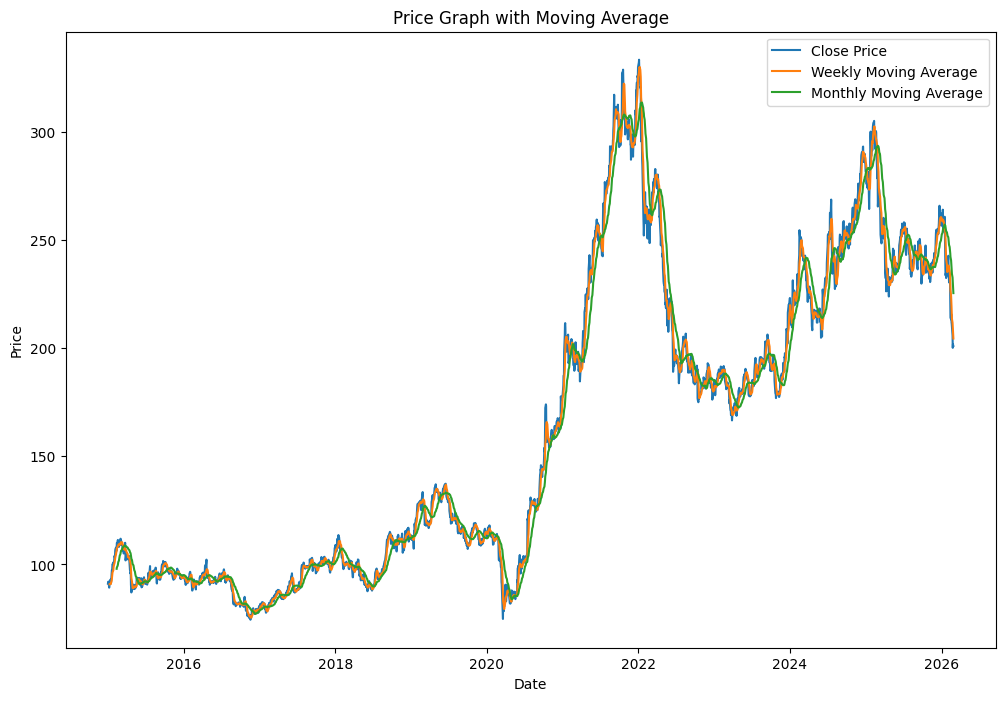

In [19]:
plt.figure(figsize=(12,8))
plt.plot(df_Wipro['Date'], df_Wipro['Close'], label='Close Price')
plt.plot(df_Wipro['Date'], df_Wipro['MA_Week'], label='Weekly Moving Average')
plt.plot(df_Wipro['Date'],df_Wipro['MA_Month'], label="Monthly Moving Average")
plt.title("Price Graph with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [20]:
df_Wipro.isnull().sum()

Date              0
Close             0
High              0
Low               0
Open              0
Volume            0
Daily_Returns     1
MA_Week           6
MA_Month         29
MA_3Months       89
dtype: int64

In [21]:
# CandleStick type of Chart
import mplfinance as mpf


# before that set the date column as index column
df_Wiproo = df_Wipro.set_index('Date')
df_Wiproo =df_Wipro.sort_index()

mpf.plot(df_Wiproo, type='candle', style='yahoo', title=f'Candlestick Chart', volume=True)


ModuleNotFoundError: No module named 'mplfinance'

In [ ]:
# Volatility to Measure the High Risk Periods
df_Wipro['volatility'] = df_Wipro['Daily_Returns'].rolling(window=3).std()

In [ ]:
# Plot Date VS Volatily
plt.figure(figsize=(10,6))
plt.plot(df_Wipro.indexdf_WiproY['volatility'])
plt.title("Volatility of the Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.show()

In [ ]:
# Check the Correlation between all the calculated values
corr_matrix = df_Wipro.select_dtypes('number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Plot Histogram for Volume to check for trading activity 
df_Wipro.plot(kind='hist', y='Volume', bins=20, title='Volume Distribution')
plt.xlabel("Volume")
plt.show()

In [ ]:
# Computing RSI (Relative Strength Index) , it measures speed and magnitude of Price Movements

# RSI compares (Average Gains VS Average Losses)

delta = df_Wipro['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain/avg_loss

df_Wipro['RSI'] = 100-(100/(1+rs))

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(df_Wipro['Close'], label= "Stock Price")
plt.title("Stock Price")
plt.legend()

plt.subplot(2,1,2)
plt.plot(df_Wipro['RSI'], label='RSI', color='purple')
plt.axhline(70, linestyle='--', color='red')  # threshold when stock is overbought
plt.axhline(30, linestyle='--', color='green') # threshold when stock is oversold

plt.title("Relative Strength INDEX (RSI)")

plt.legend()
plt.tight_layout()
plt.show()

### Creating Prediction Target

In [ ]:
# if next day's return > 0 then target = 1 else 0


df_Wipro['Next_Day_Return'] =df_Wipro['Daily_Returns'].shift(-1)
df_Wipro['Target'] = (df_Wipro['Next_Day_Return'] > 0).astype(int)

In [ ]:
df_Wipro = df_Wipro.dropna()

In [ ]:
df_Wipro.info()

### Time Based Train Test Split

In [ ]:
df_Wipro =df_Wipro.sort_index()
split_index = int(len(df_Wipro)*0.8)

train = df_Wipro.iloc[0:split_index]
test = df_Wipro.iloc[split_index: len(df_Wipro)]


print(f"Training ENDS: {train.index.max()}")
print(f"Testing Starts: {test.index.min()}")

In [ ]:
y_train = train['Target']
y_test = test['Target']



features=['Daily_Returns', 'Volume', 'volatility', 'MA_Week', 'MA_Month', 'MA_3Months', 'RSI']
X_train = train[features]
X_test = test[features]

### Fearture Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()